# 02 - Funnel Drop-off Analysis
Uses `mart_landlord_funnel` (built with SQL window functions and conditional
aggregation) to find WHERE landlords abandon onboarding, and for WHICH
segments the drop-off is worst -- not just where the biggest average drop is.

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect("../data/warehouse.db")
funnel = pd.read_sql("SELECT * FROM mart_landlord_funnel", conn)
funnel.head()

## Step 1: Overall funnel shape

pct_property_added             0.404
pct_listing_published          0.337
pct_tenant_invited             0.255
pct_rent_collection_enabled    0.050
pct_paid_conversion            0.103
dtype: float64


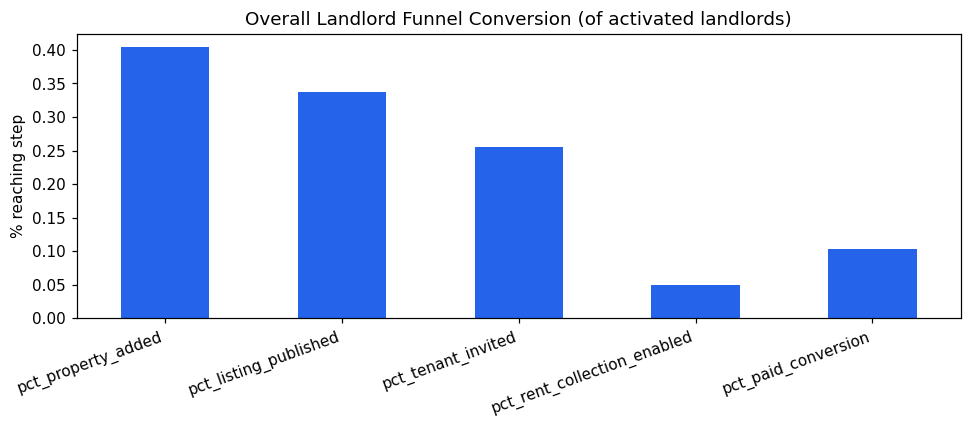

In [2]:
steps = ["pct_property_added", "pct_listing_published", "pct_tenant_invited",
         "pct_rent_collection_enabled", "pct_paid_conversion"]
overall = (funnel[steps].mul(funnel["landlords"], axis=0).sum() / funnel["landlords"].sum())
print(overall.round(3))

fig, ax = plt.subplots(figsize=(9, 4))
overall.plot(kind="bar", ax=ax, color="#2563eb")
ax.set_title("Overall Landlord Funnel Conversion (of activated landlords)")
ax.set_ylabel("% reaching step")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

The naive read is "listing publication has the largest drop." That's true on
average -- but it hides which *segments* are driving it. Breaking the same
step down by channel x device below is where the actionable insight is.

## Step 2: Which channel x device combos have strong signup volume but weak
activation-to-publish follow-through?

In [3]:
by_channel_device = (
    funnel.groupby(["acquisition_channel", "signup_device"])
    .apply(lambda g: pd.Series({
        "landlords": g["landlords"].sum(),
        "pct_listing_published": (g["pct_listing_published"] * g["landlords"]).sum() / g["landlords"].sum(),
        "publish_abandonment_rate": (g["publish_abandonment_rate"] * g["landlords"]).sum() / g["landlords"].sum(),
        "avg_days_to_publish": (g["avg_days_to_publish"].fillna(0) * g["landlords"]).sum() / g["landlords"].sum(),
    }), include_groups=False)
    .reset_index()
    .sort_values("landlords", ascending=False)
)
by_channel_device.round(3).head(15)

## Step 3: Isolate the worst combination by volume-weighted abandonment

In [4]:
sizeable = by_channel_device[by_channel_device["landlords"] >= 200]
worst = sizeable.sort_values("publish_abandonment_rate", ascending=False).head(5)
best = sizeable.sort_values("publish_abandonment_rate", ascending=True).head(5)
print("WORST activation-to-publish segments (min 200 landlords):")
print(worst[["acquisition_channel", "signup_device", "landlords", "publish_abandonment_rate", "avg_days_to_publish"]].to_string(index=False))
print("\nBEST activation-to-publish segments:")
print(best[["acquisition_channel", "signup_device", "landlords", "publish_abandonment_rate", "avg_days_to_publish"]].to_string(index=False))

WORST activation-to-publish segments (min 200 landlords):
acquisition_channel signup_device  landlords  publish_abandonment_rate  avg_days_to_publish
        paid_social        mobile     5071.0                  0.408839             4.208724
        paid_search        mobile     4757.0                  0.326677             4.044320
        content_seo        mobile     3044.0                  0.316887             3.778578
        paid_social        tablet      773.0                  0.306355             2.625433
        paid_search        tablet      717.0                  0.284935             2.694086

BEST activation-to-publish segments:
acquisition_channel signup_device  landlords  publish_abandonment_rate  avg_days_to_publish
           referral       desktop     2857.0                  0.014713             2.262475
       partnerships       desktop     1582.0                  0.025101             2.129482
     organic_search       desktop     5523.0                  0.046875      

## Step 4: Portfolio-size and metro cuts

In [5]:
by_portfolio = (
    funnel.groupby("portfolio_segment")
    .apply(lambda g: pd.Series({
        "landlords": g["landlords"].sum(),
        "pct_paid_conversion": (g["pct_paid_conversion"] * g["landlords"]).sum() / g["landlords"].sum(),
    }), include_groups=False)
)
print(by_portfolio.round(3))

top_metros = (
    funnel.groupby("metro_id")
    .apply(lambda g: pd.Series({
        "landlords": g["landlords"].sum(),
        "pct_paid_conversion": (g["pct_paid_conversion"] * g["landlords"]).sum() / g["landlords"].sum(),
    }), include_groups=False)
    .sort_values("landlords", ascending=False)
    .head(8)
)
print("\nHigh-volume metros, paid conversion:")
print(top_metros.round(3))

                   landlords  pct_paid_conversion
portfolio_segment                                
large_10plus          8533.0                0.167
medium_4to9          10155.0                0.112
small_1to3           31312.0                0.083

High-volume metros, paid conversion:
          landlords  pct_paid_conversion
metro_id                                
M012         3253.0                0.117
M001         3038.0                0.105
M004         2753.0                0.113
M017         2730.0                0.107
M015         2656.0                0.110
M006         2566.0                0.102
M014         2524.0                0.099
M003         2517.0                0.103


## Finding

Mobile-acquired landlords consistently show a higher listing-publish
abandonment rate and a longer average time-to-publish than desktop landlords
across every channel, and the effect compounds for paid-social specifically
(highest CAC channel, weakest mobile follow-through). Large-portfolio
landlords (10+ units) convert to paid at a materially higher rate than
small landlords, consistent with them having more to gain from paid
features like bulk rent collection.

**Recommendation:** Prioritize a simplified mobile property/listing setup
flow (fewer required fields, save-and-resume) before spending further on
mobile paid-social acquisition -- the channel is bringing in volume the
product isn't currently converting to published listings.